In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import scikit_posthocs as sp

from itertools import cycle

In [28]:
df = pd.read_excel('01_2024-344-C-01-I_Original_data 代谢原始数据.xlsx',index_col=0)

In [29]:
VEN_samples = ['VEN_1_S', 'VEN_2','VEN_3', 'VEN_4', 'VEN_5','VEN_1_Q']
LIP_samples = ['LIP_1_Q', 'LIP_1_S', 'LIP_2', 'LIP_3','LIP_4', 'LIP_5']
V1_samples  = ['V1_1', 'V1_2_Q', 'V1_2_S', 'V1_3','V1_4_Q','V1_4_S', 'V1_5']

In [30]:
#numeric_cols = df.select_dtypes(include=[np.number]).columns
#df[numeric_cols] = np.log10(df[numeric_cols] + 1e-9)

In [31]:
# Glycolysis
#metabolites = [
#    'Glucose',
#    'Glucose 6-phosphate',
#    'Fructose 6-phosphate',
#    'Fructose 1,6-bisphosphate',
#    'Dihydroxyacetone phosphate',
#    'Glycerol 3-phosphate',
#    '3-Phosphoglyceric acid',
#    'Pyruvate'
#     L-Lactic acid
#]

In [32]:
#TCA
#metabolites = [
#    'Oxalacetate',
#    'Citric acid',
#    '2-Ketobutyric acid',
#    'Succinic acid',
#    'Fumaric acid',
#    'L-Malic acid',
#]

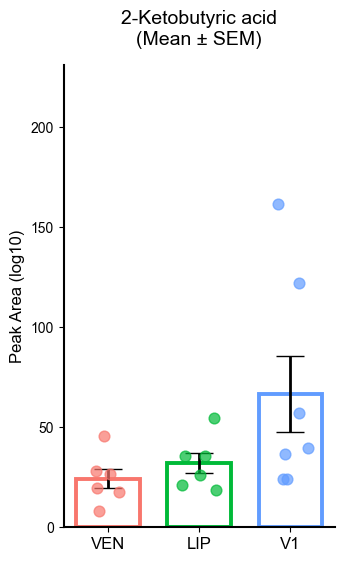

In [47]:
plt.close('all')
# 设置全局字体为Arial，确保AI中可编辑
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42  # 确保字体在AI中可编辑

fig, ax = plt.subplots(figsize=(3.5, 6))

selected_metab = '2-Ketobutyric acid'
                  
ven_data = df.loc[selected_metab, VEN_samples].values
lip_data = df.loc[selected_metab, LIP_samples].values
v1_data = df.loc[selected_metab, V1_samples].values

dunn_df = pd.DataFrame({
    'value': np.concatenate([ven_data, lip_data, v1_data]),
    'group': ['VEN']*len(ven_data) + ['LIP']*len(lip_data) + ['V1']*len(v1_data)
})
dunn_res = sp.posthoc_dunn(dunn_df, val_col='value', group_col='group', p_adjust='holm')

means = [np.mean(ven_data), np.mean(lip_data), np.mean(v1_data)]
stds = [np.std(ven_data), np.std(lip_data), np.std(v1_data)]
sems = [stds[i]/np.sqrt(len([ven_data, lip_data, v1_data][i])) for i in range(3)]

group_colors = {'VEN':'#f8766d', 'LIP':'#00ba38', 'V1':'#619cff'}
group_names = ['VEN', 'LIP', 'V1']
positions = np.arange(len(group_names)) * 0.5

data_min = min(np.min(ven_data), np.min(lip_data), np.min(v1_data))
data_max = max(np.max(ven_data), np.max(lip_data), np.max(v1_data))
data_range = data_max - data_min
y_padding = data_range * 0.15
max_val = data_max + y_padding * 3
ax.set_ylim(max(0, data_min - y_padding), max_val)

# 加粗柱状图边框线条 - 从2增加到2.8
bars = ax.bar(positions, means, width=0.35,
              color='none',
              alpha=1.0, 
              edgecolor=[group_colors[g] for g in group_names],
              linewidth=2.8,  # 增加边框粗细
              yerr=sems, capsize=10, error_kw={'elinewidth': 2}) 

for i, color in enumerate(group_colors.values()):
    data = [ven_data, lip_data, v1_data][i]
    jitter = 0.1 * np.random.uniform(-1, 1, size=len(data))
    x_pos = positions[i] + jitter
    ax.scatter(x_pos, data, color=color, s=60, alpha=0.7, zorder=10)

max_data_point = np.max(np.concatenate([ven_data, lip_data, v1_data]))
marker_height = max_data_point + data_range * 0.2
step_height = data_range * 0.1

comparisons = [('VEN', 'LIP'), ('VEN', 'V1'), ('LIP', 'V1')]
for i, (g1, g2) in enumerate(comparisons):
    p_val = dunn_res.loc[g1, g2]
    if p_val >= 0.05:
        continue
        
    x1 = positions[group_names.index(g1)]
    x2 = positions[group_names.index(g2)]
    current_height = marker_height + i * step_height
    
    # 也加粗显著性标记线条
    ax.plot([x1, x2], [current_height, current_height], 
            color='black', linewidth=1.8)  # 从1.5增加到1.8
    ax.plot([x1, x1], [current_height, current_height - step_height/3], 
            color='black', linewidth=1.8)  # 从1.5增加到1.8
    ax.plot([x2, x2], [current_height, current_height - step_height/3], 
            color='black', linewidth=1.8)  # 从1.5增加到1.8
    
    if p_val < 0.001:
        sig = '***'
    elif p_val < 0.01:
        sig = '**'
    else:
        sig = '*'
    
    # 使用常规字体而非粗体，便于AI编辑
    ax.text((x1+x2)/2, current_height + step_height/5, sig, 
            ha='center', va='bottom', fontsize=12)  # 移除了weight='bold'

# 图表标注优化 - 使用明确字体设置
ax.set_xticks(positions)
ax.set_xticklabels(group_names, fontsize=12)
ax.set_ylabel('Peak Area (log10)', fontsize=12)
ax.set_title(f"{selected_metab}\n(Mean ± SEM)", fontsize=14, pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_visible(True)

# 加粗坐标轴线条
ax.spines[['left', 'bottom']].set_linewidth(1.5)  # 加粗边框

#plt.savefig(f"{selected_metab}_barplot.pdf", dpi=300, bbox_inches='tight')
#plt.savefig(f"{selected_metab}_barplot.png", dpi=300, bbox_inches='tight')

plt.show()

In [36]:
# Glycolysis and TCA
metabolites_list = [
    'Glucose',
    'Glucose 6-phosphate',
    'Fructose 6-phosphate',
    'Fructose 1,6-bisphosphate',
    'Dihydroxyacetone phosphate',
    'Glycerol 3-phosphate',
    '3-Phosphoglyceric acid',
    'Pyruvate',
    'Oxalacetate',
    'Citric acid',
    '2-Ketobutyric acid',
    'Succinic acid',
    'Fumaric acid',
    'L-Malic acid',
    'L-Lactic acid'
]

In [37]:
#氨基酸
#metabolites_list = [
#    'L-Glutamic acid',
#    'L-Glutamine',
#    'L-Proline',
#    'L-Asparagine',
#    'L-Aspartic acid',
#    'L-Histidine',
#    'L-Arginine',
#    'L-Methionine',
#    'L-Isoleucine',
#    'L-Valine',
#    'L-Threonine',
#    'L-Phenylalanine',
#    'L-Tyrosine',
#    'L-Lysine',
#    'L-Leucine',
#    'L-Tryptophan'
#]

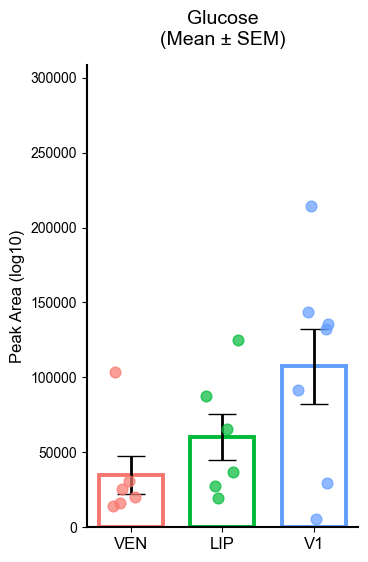

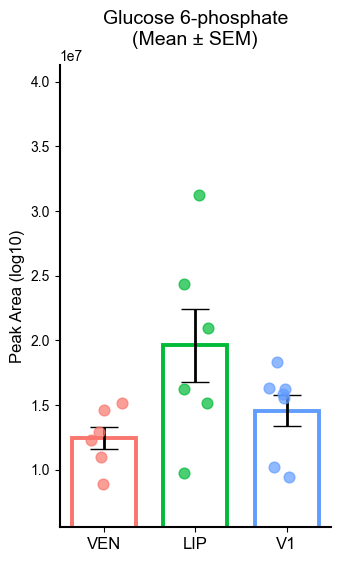

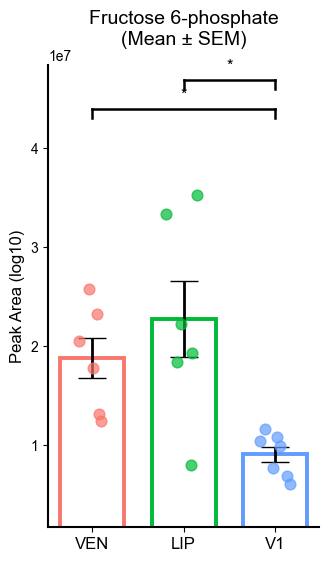

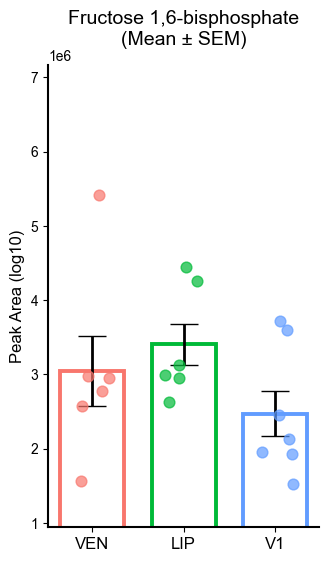

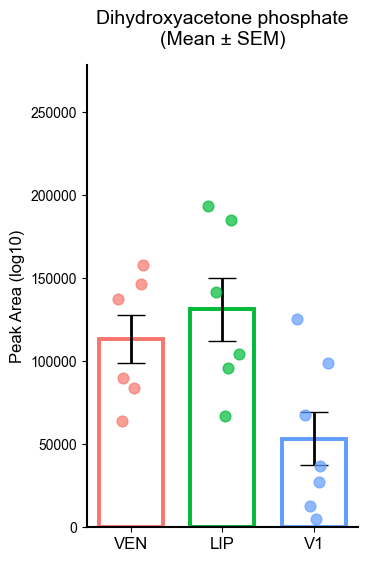

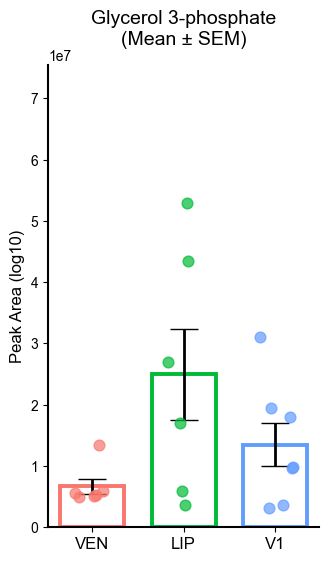

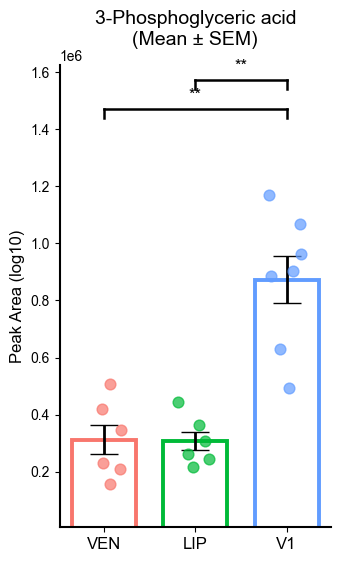

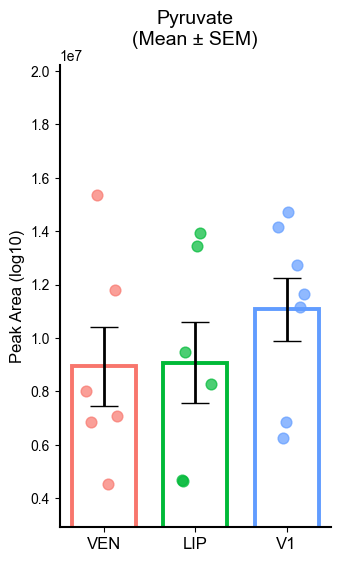

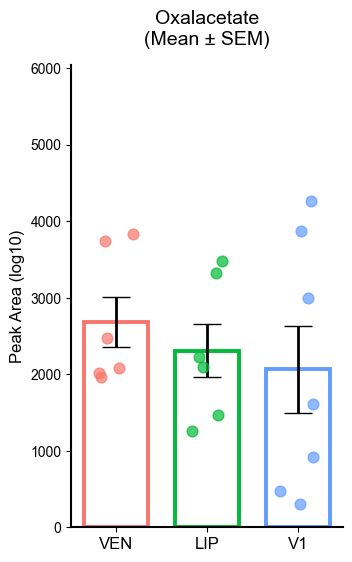

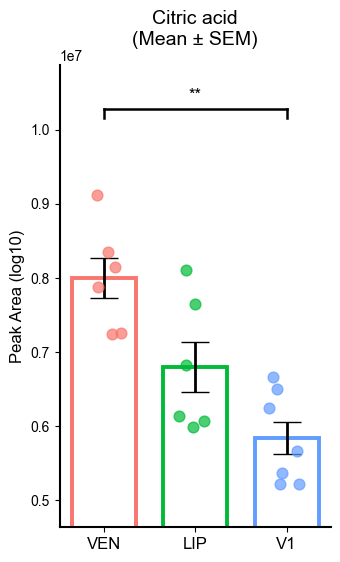

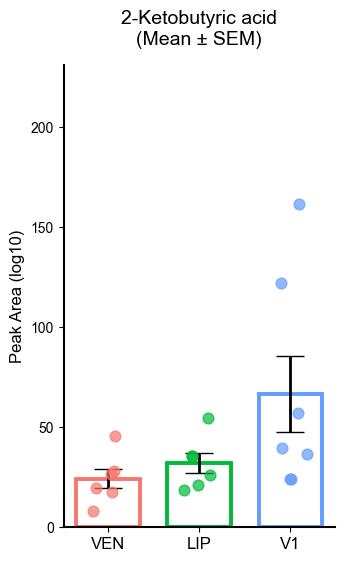

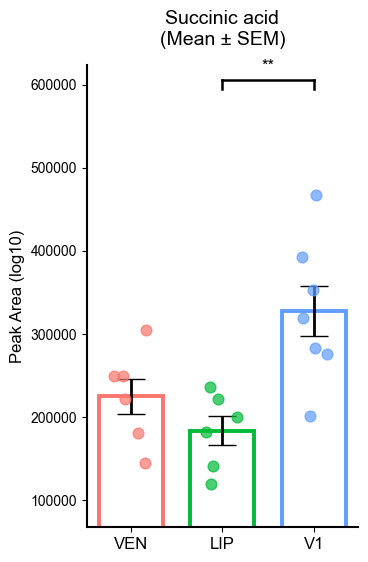

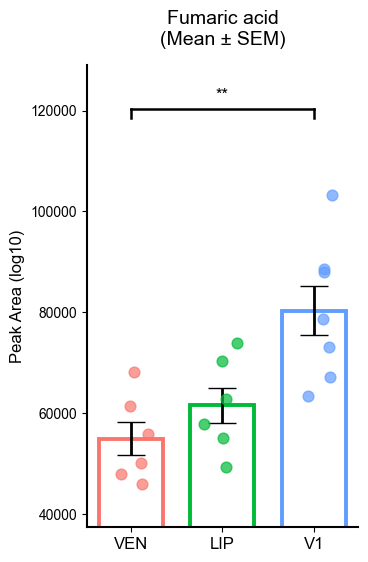

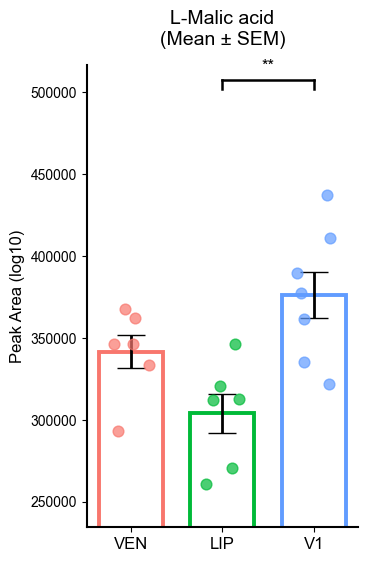

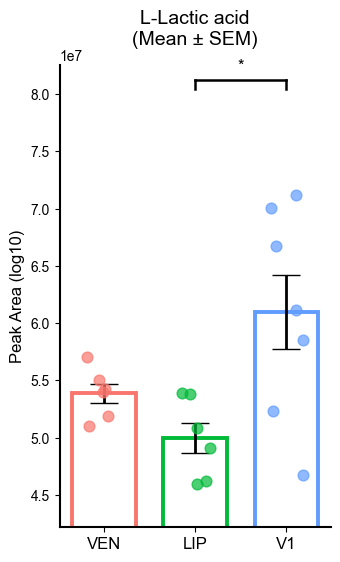

In [48]:
plt.close('all')
# 设置全局字体为Arial，确保AI中可编辑
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42  # 确保字体在AI中可编辑
    
   # selected_metab = 'Oxalacetate'
for selected_metab in metabolites_list:
    fig, ax = plt.subplots(figsize=(3.5, 6))   
    ven_data = df.loc[selected_metab, VEN_samples].values
    lip_data = df.loc[selected_metab, LIP_samples].values
    v1_data = df.loc[selected_metab, V1_samples].values
    
    dunn_df = pd.DataFrame({
        'value': np.concatenate([ven_data, lip_data, v1_data]),
        'group': ['VEN']*len(ven_data) + ['LIP']*len(lip_data) + ['V1']*len(v1_data)
    })
    dunn_res = sp.posthoc_dunn(dunn_df, val_col='value', group_col='group', p_adjust='holm')
    
    means = [np.mean(ven_data), np.mean(lip_data), np.mean(v1_data)]
    stds = [np.std(ven_data), np.std(lip_data), np.std(v1_data)]
    sems = [stds[i]/np.sqrt(len([ven_data, lip_data, v1_data][i])) for i in range(3)]
    
    group_colors = {'VEN':'#f8766d', 'LIP':'#00ba38', 'V1':'#619cff'}
    group_names = ['VEN', 'LIP', 'V1']
    positions = np.arange(len(group_names)) * 0.5
    
    data_min = min(np.min(ven_data), np.min(lip_data), np.min(v1_data))
    data_max = max(np.max(ven_data), np.max(lip_data), np.max(v1_data))
    data_range = data_max - data_min
    y_padding = data_range * 0.15
    max_val = data_max + y_padding * 3
    ax.set_ylim(max(0, data_min - y_padding), max_val)
    
    # 加粗柱状图边框线条 - 从2增加到2.8
    bars = ax.bar(positions, means, width=0.35,
                  color='none',
                  alpha=1.0, 
                  edgecolor=[group_colors[g] for g in group_names],
                  linewidth=2.8,  # 增加边框粗细
                  yerr=sems, capsize=10, error_kw={'elinewidth': 2}) 
    
    for i, color in enumerate(group_colors.values()):
        data = [ven_data, lip_data, v1_data][i]
        jitter = 0.1 * np.random.uniform(-1, 1, size=len(data))
        x_pos = positions[i] + jitter
        ax.scatter(x_pos, data, color=color, s=60, alpha=0.7, zorder=10)
    
    max_data_point = np.max(np.concatenate([ven_data, lip_data, v1_data]))
    marker_height = max_data_point + data_range * 0.2
    step_height = data_range * 0.1
    
    comparisons = [('VEN', 'LIP'), ('VEN', 'V1'), ('LIP', 'V1')]
    for i, (g1, g2) in enumerate(comparisons):
        p_val = dunn_res.loc[g1, g2]
        if p_val >= 0.05:
            continue
            
        x1 = positions[group_names.index(g1)]
        x2 = positions[group_names.index(g2)]
        current_height = marker_height + i * step_height
        
        # 也加粗显著性标记线条
        ax.plot([x1, x2], [current_height, current_height], 
                color='black', linewidth=1.8)  # 从1.5增加到1.8
        ax.plot([x1, x1], [current_height, current_height - step_height/3], 
                color='black', linewidth=1.8)  # 从1.5增加到1.8
        ax.plot([x2, x2], [current_height, current_height - step_height/3], 
                color='black', linewidth=1.8)  # 从1.5增加到1.8
        
        if p_val < 0.001:
            sig = '***'
        elif p_val < 0.01:
            sig = '**'
        else:
            sig = '*'
        
        # 使用常规字体而非粗体，便于AI编辑
        ax.text((x1+x2)/2, current_height + step_height/5, sig, 
                ha='center', va='bottom', fontsize=12)  # 移除了weight='bold'
    
    # 图表标注优化 - 使用明确字体设置
    ax.set_xticks(positions)
    ax.set_xticklabels(group_names, fontsize=12)
    ax.set_ylabel('Peak Area (log10)', fontsize=12)
    ax.set_title(f"{selected_metab}\n(Mean ± SEM)", fontsize=14, pad=15)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_visible(True)
    
    # 加粗坐标轴线条
    ax.spines[['left', 'bottom']].set_linewidth(1.5)  # 加粗边框
    
    #plt.savefig(f"{selected_metab}_barplot.pdf", dpi=300, bbox_inches='tight')
    #plt.savefig(f"{selected_metab}_barplot.png", dpi=300, bbox_inches='tight')
    
    #plt.show()

Metabolite: Glucose
Kruskal-Wallis H-statistic: 4.510
Kruskal-Wallis p-value: 1.049e-01
Kruskal-Wallis test is NOT significant, skipping Dunn's post-hoc test.


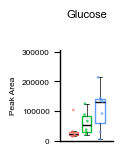

Metabolite: Glucose 6-phosphate
Kruskal-Wallis H-statistic: 5.393
Kruskal-Wallis p-value: 6.743e-02
Kruskal-Wallis test is NOT significant, skipping Dunn's post-hoc test.


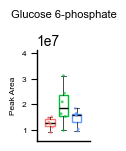

Metabolite: Fructose 6-phosphate
Kruskal-Wallis H-statistic: 10.356
Kruskal-Wallis p-value: 5.638e-03
Kruskal-Wallis test is significant, proceeding with Dunn's post-hoc test.


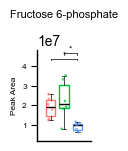

Metabolite: Fructose 1,6-bisphosphate
Kruskal-Wallis H-statistic: 4.131
Kruskal-Wallis p-value: 1.268e-01
Kruskal-Wallis test is NOT significant, skipping Dunn's post-hoc test.


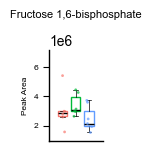

Metabolite: Dihydroxyacetone phosphate
Kruskal-Wallis H-statistic: 6.326
Kruskal-Wallis p-value: 4.231e-02
Kruskal-Wallis test is significant, proceeding with Dunn's post-hoc test.


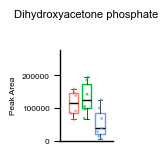

Metabolite: Glycerol 3-phosphate
Kruskal-Wallis H-statistic: 3.411
Kruskal-Wallis p-value: 1.817e-01
Kruskal-Wallis test is NOT significant, skipping Dunn's post-hoc test.


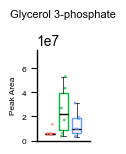

Metabolite: 3-Phosphoglyceric acid
Kruskal-Wallis H-statistic: 12.031
Kruskal-Wallis p-value: 2.441e-03
Kruskal-Wallis test is significant, proceeding with Dunn's post-hoc test.


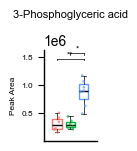

Metabolite: Pyruvate
Kruskal-Wallis H-statistic: 0.867
Kruskal-Wallis p-value: 6.483e-01
Kruskal-Wallis test is NOT significant, skipping Dunn's post-hoc test.


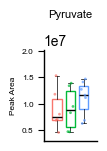

Metabolite: Oxalacetate
Kruskal-Wallis H-statistic: 0.720
Kruskal-Wallis p-value: 6.976e-01
Kruskal-Wallis test is NOT significant, skipping Dunn's post-hoc test.


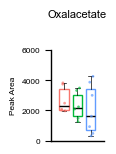

Metabolite: Citric acid
Kruskal-Wallis H-statistic: 11.002
Kruskal-Wallis p-value: 4.082e-03
Kruskal-Wallis test is significant, proceeding with Dunn's post-hoc test.


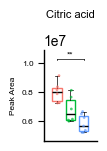

Metabolite: 2-Ketobutyric acid
Kruskal-Wallis H-statistic: 4.630
Kruskal-Wallis p-value: 9.876e-02
Kruskal-Wallis test is NOT significant, skipping Dunn's post-hoc test.


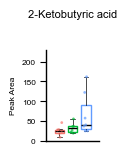

Metabolite: Succinic acid
Kruskal-Wallis H-statistic: 9.531
Kruskal-Wallis p-value: 8.519e-03
Kruskal-Wallis test is significant, proceeding with Dunn's post-hoc test.


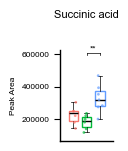

Metabolite: Fumaric acid
Kruskal-Wallis H-statistic: 9.700
Kruskal-Wallis p-value: 7.828e-03
Kruskal-Wallis test is significant, proceeding with Dunn's post-hoc test.


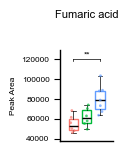

Metabolite: L-Malic acid
Kruskal-Wallis H-statistic: 9.231
Kruskal-Wallis p-value: 9.898e-03
Kruskal-Wallis test is significant, proceeding with Dunn's post-hoc test.


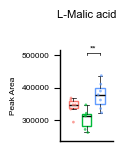

Metabolite: L-Lactic acid
Kruskal-Wallis H-statistic: 7.523
Kruskal-Wallis p-value: 2.325e-02
Kruskal-Wallis test is significant, proceeding with Dunn's post-hoc test.


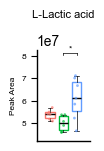

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scikit_posthocs as sp  # 导入 scikit-posthocs 用于 posthoc_dunn
from matplotlib.ticker import ScalarFormatter  # 用于优化Y轴显示（如果需要）
from scipy import stats

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42  # 确保字体在AI中可编辑

# 设置图形尺寸，30mm转换为英寸
new_height_inch = 30 / 25.4
original_aspect_ratio = 3.5 / 6
new_width_inch = new_height_inch * original_aspect_ratio

# 遍历代谢物列表
for selected_metab in metabolites_list:
    # 创建图形和轴
    fig, ax = plt.subplots(figsize=(new_width_inch, new_height_inch))
    ven_data = df.loc[selected_metab, VEN_samples].values
    lip_data = df.loc[selected_metab, LIP_samples].values
    v1_data = df.loc[selected_metab, V1_samples].values
    kruskal_statistic, kruskal_p_value = stats.kruskal(ven_data, lip_data, v1_data)
    print(f"Metabolite: {selected_metab}")
    print(f"Kruskal-Wallis H-statistic: {kruskal_statistic:.3f}")
    print(f"Kruskal-Wallis p-value: {kruskal_p_value:.3e}") # 使用科学计数法显示p值

    # 通常只在 Kruskal-Wallis test 显著时才进行 Dunn's test
    if kruskal_p_value < 0.05: # 设置显著性水平
        print("Kruskal-Wallis test is significant, proceeding with Dunn's post-hoc test.")
        # 准备Dunn检验数据
        dunn_df = pd.DataFrame({
            'value': np.concatenate([ven_data, lip_data, v1_data]),
            'group': ['VEN']*len(ven_data) + ['LIP']*len(lip_data) + ['V1']*len(v1_data)
        })
        dunn_res = sp.posthoc_dunn(dunn_df, val_col='value', group_col='group', p_adjust='bonferroni')
    else:
        print("Kruskal-Wallis test is NOT significant, skipping Dunn's post-hoc test.")
        # 如果不显著，可以设置 dunn_res 为 None 或者一个空的 DataFrame，
        # 这样下面的显著性标记代码就不会执行。
        dunn_res = pd.DataFrame(index=['VEN', 'LIP', 'V1'], columns=['VEN', 'LIP', 'V1'], data=1.0)
    # 准备Dunn检验数据
    dunn_df = pd.DataFrame({
        'value': np.concatenate([ven_data, lip_data, v1_data]),
        'group': ['VEN']*len(ven_data) + ['LIP']*len(lip_data) + ['V1']*len(v1_data)
    })
    dunn_res = sp.posthoc_dunn(dunn_df, val_col='value', group_col='group', p_adjust='bonferroni')

    # 计算均值、标准差和标准误（虽未直接使用，但保留以备后续）
    means = [np.mean(ven_data), np.mean(lip_data), np.mean(v1_data)]
    stds = [np.std(ven_data), np.std(lip_data), np.std(v1_data)]
    sems = [stds[i]/np.sqrt(len([ven_data, lip_data, v1_data][i])) for i in range(3)]

    # 定义组颜色和名称
    group_colors = {'VEN': '#f8766d', 'LIP': '#00ba38', 'V1': '#619cff'}
    group_names = ['VEN', 'LIP', 'V1']
    positions = np.arange(len(group_names)) * 0.5

    # 计算Y轴范围
    data_min = min(np.min(ven_data), np.min(lip_data), np.min(v1_data))
    data_max = max(np.max(ven_data), np.max(lip_data), np.max(v1_data))
    data_range = data_max - data_min
    y_padding = data_range * 0.15
    max_val = data_max + y_padding * 3
    ax.set_ylim(max(0, data_min - y_padding), max_val)

    # 设置箱线图（无填充，仅彩色边框）
    box = ax.boxplot(
        [ven_data, lip_data, v1_data],
        positions=positions,
        widths=0.35,
        patch_artist=True,  # 允许自定义颜色
        showfliers=False,  # 不显示离群点，避免与散点重叠
        boxprops=dict(linewidth=1, facecolor='none'),  # 无填充，线宽1
        whiskerprops=dict(linewidth=0.5, color='black'),  # 须线为黑色细线
        capprops=dict(linewidth=0.5, color='black'),  # 帽线为黑色细线
        medianprops=dict(linewidth=1, color='black')  # 中位线为黑色
    )
    # 设置箱线图边框颜色为组颜色
    for patch, color in zip(box['boxes'], [group_colors[g] for g in group_names]):
        patch.set_edgecolor(color)  # 使用彩色边框
        patch.set_facecolor('none')  # 确保无填充

    # 设置散点大小
    scatter_marker_size = 20 * (new_height_inch / 6)

    # 绘制散点图
    for i, color in enumerate(group_colors.values()):
        data = [ven_data, lip_data, v1_data][i]
        jitter = 0.1 * np.random.uniform(-1, 1, size=len(data))
        x_pos = positions[i] + jitter
        ax.scatter(x_pos, data, color=color, s=scatter_marker_size, alpha=0.7, zorder=10, edgecolor='none')

    # 设置显著性标记位置
    max_data_point = np.max(np.concatenate([ven_data, lip_data, v1_data]))
    marker_height = max_data_point + data_range * 0.2
    step_height = data_range * 0.1

    comparisons = [('VEN', 'LIP'), ('VEN', 'V1'), ('LIP', 'V1')]
    significance_font_size = 6  # 显著性标记字体大小
    line_width = 1.5 * (new_height_inch / 6)  # 连接线宽度（虽未直接使用，但保留）

    # 绘制显著性标记
    for i, (g1, g2) in enumerate(comparisons):
        p_val = dunn_res.loc[g1, g2]
        if p_val >= 0.05:
            continue

        x1 = positions[group_names.index(g1)]
        x2 = positions[group_names.index(g2)]
        current_height = marker_height + i * step_height

        # 绘制显著性连接线
        ax.plot([x1, x2], [current_height, current_height], color='black', linewidth=0.5)
        ax.plot([x1, x1], [current_height, current_height - step_height/3], color='black', linewidth=0.5)
        ax.plot([x2, x2], [current_height, current_height - step_height/3], color='black', linewidth=0.5)

        # 根据p值确定星号数量
        if p_val < 0.001:
            sig = '***'
        elif p_val < 0.01:
            sig = '**'
        else:
            sig = '*'

        # 绘制显著性星号
        ax.text((x1+x2)/2, current_height + step_height/5, sig, ha='center', va='bottom', fontsize=significance_font_size)

    # 隐藏X轴刻度线和组名
    ax.set_xticks([])  # 移除X轴刻度线和标签

    ax.set_ylabel('Peak Area', fontsize=6)  # Y轴标签
    ax.set_title(f"{selected_metab}\n", fontsize=8, pad=15)  # 标题
    ax.spines[['top', 'right']].set_visible(False)  # 隐藏顶部和右侧边框
    ax.spines[['left', 'bottom']].set_visible(True)
    ax.spines[['left', 'bottom']].set_linewidth(1)  # 设置边框宽度

    # 优化Y轴刻度显示（如果需要添加，可取消注释）
    # ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))  # 使用简单数字格式
    # ax.yaxis.get_major_formatter().set_scientific(False)  # 禁用科学计数法
    # ax.yaxis.get_major_formatter().set_useOffset(False)  # 禁用偏移
    ax.tick_params(axis='y', labelsize=6, direction='out', length=4)  # 紧凑刻度设置
    ax.set_ylim(max(0, data_min - y_padding), max_val)  # 保持Y轴范围

    # 保存图形（已注释，如果需要可取消）
    plt.savefig(f"{selected_metab}_barplot.pdf", dpi=300, bbox_inches='tight')
    plt.savefig(f"{selected_metab}_barplot.png", dpi=300, bbox_inches='tight')

    # 显示图形
    plt.show()